# FIRMS NRT and WFIGS Current data

purpose of this notebook is to get familiar with the live APIs for FIRMS and WFIGS and how the live/near-real-time data works/looks like. Looking at VIIRS NOAA-20 hotspts for CA and overlaying them against WFIGS active perimeters.

In [1]:
import os
import pandas as pd
import requests
from io import StringIO, BytesIO
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Point
from dotenv import load_dotenv

os.makedirs("plots", exist_ok=True)
os.makedirs("plots/eda_firms_wfigs_current", exist_ok=True)
load_dotenv()

True

In [2]:
MAP_KEY = os.getenv("MAP_KEY", "<get_your_own_key_buddy>")

In [4]:
# CA bbox
bbox = "-124.41060660766607,32.5342307609976,-114.13445790587905,42.00965914828148"
days = 5
url = f"https://firms.modaps.eosdis.nasa.gov/api/area/csv/{MAP_KEY}/VIIRS_NOAA20_NRT/{bbox}/{days}"
resp = requests.get(url, timeout=30)
resp.raise_for_status()
data = resp.content.decode("utf-8")
df = pd.read_csv(StringIO(data))
df["acq_datetime"] = pd.to_datetime(
    df["acq_date"].astype(str) + " " + df["acq_time"].astype(str).str.zfill(4),
    format="%Y-%m-%d %H%M",
    utc=True,
)

df.head()

,latitude,longitude,bright_ti4,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_ti5,frp,daynight,acq_datetime
0,40.82118,-114.25632,300.13,0.78,0.78,2026-06-14,824,N20,VIIRS,n,2.0NRT,284.91,1.79,N,2026-06-14 08:24:00+00:00
1,40.82126,-114.25646,316.25,0.42,0.45,2026-06-14,1004,N20,VIIRS,n,2.0NRT,286.86,2.54,N,2026-06-14 10:04:00+00:00
2,34.14363,-117.42599,308.15,0.40,0.44,2026-06-14,1006,N20,VIIRS,n,2.0NRT,290.73,0.47,N,2026-06-14 10:06:00+00:00
3,34.35585,-116.85089,306.43,0.42,0.46,2026-06-14,1006,N20,VIIRS,n,2.0NRT,293.64,0.72,N,2026-06-14 10:06:00+00:00
4,34.43180,-118.64411,306.41,0.52,0.41,2026-06-14,1006,N20,VIIRS,n,2.0NRT,288.29,1.31,N,2026-06-14 10:06:00+00:00


In [6]:
geometry = [Point(xy) for xy in zip(df["longitude"], df["latitude"])]
fire_gdf = gpd.GeoDataFrame(df, geometry=geometry, crs="EPSG:4326")

print(f"Total hotspots: {len(fire_gdf)}")
display(fire_gdf["geometry"].head())

Total hotspots: 484


0    POINT (-114.25632 40.82118)
1    POINT (-114.25646 40.82126)
2    POINT (-117.42599 34.14363)
3    POINT (-116.85089 34.35585)
4     POINT (-118.64411 34.4318)
Name: geometry, dtype: geometry

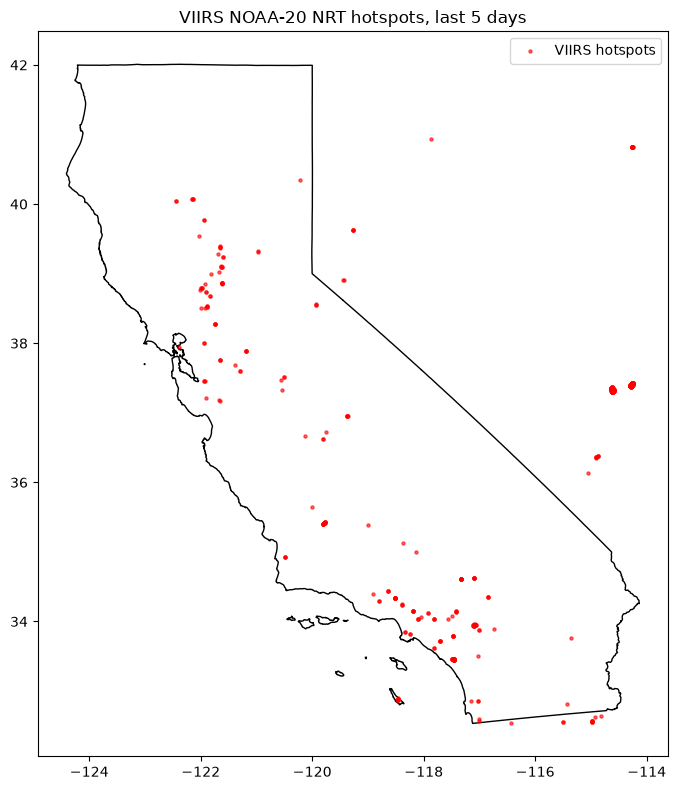

In [8]:
# CA boundary
resp = requests.get(
    "https://www2.census.gov/geo/tiger/GENZ2022/shp/cb_2022_us_state_500k.zip",
    timeout=30,
)
resp.raise_for_status()
states_gdf = gpd.read_file(BytesIO(resp.content))
ca = states_gdf[states_gdf["NAME"] == "California"]

fig, ax = plt.subplots(figsize=(8, 8))
ca.plot(ax=ax, color="none", edgecolor="black", linewidth=1)
fire_gdf.plot(ax=ax, color="red", markersize=5, alpha=0.6, label="VIIRS hotspots")
ax.set_title(f"VIIRS NOAA-20 NRT hotspots, last {days} days")
ax.legend()
plt.tight_layout()
plt.savefig(
    "plots/eda_firms_wfigs_current/w1_nrt_hotspots.png", dpi=150, bbox_inches="tight"
)
plt.show()

In [9]:
# WFIGS current fire perimeters
wfigs_url = (
    "https://services3.arcgis.com/T4QMspbfLg3qTGWY/arcgis/rest/services"
    "/WFIGS_Interagency_Perimeters_Current/FeatureServer/0/query"
)

params = {
    "where": "1=1",
    "outFields": "*",
    "outSR": "4326",
    "f": "geojson",
}

resp = requests.get(wfigs_url, params=params, timeout=30)
resp.raise_for_status()
perimeters_gdf = gpd.read_file(BytesIO(resp.content))

print(f"Active perimeters nationally: {len(perimeters_gdf)}")
perimeters_gdf.head()

Active perimeters nationally: 95


,OBJECTID,poly_SourceOID,poly_IncidentName,poly_FeatureCategory,poly_MapMethod,poly_GISAcres,poly_DeleteThis,poly_FeatureAccess,poly_FeatureStatus,poly_IsVisible,...,attr_ActiveFireCandidate,attr_IsCpxChild,attr_CpxName,attr_CpxID,attr_SourceGlobalID,GlobalID,Shape__Area,Shape__Length,attr_IncidentComplexityLevel,geometry
0,51675,8100,BLIZZARD,Wildfire Daily Fire Perimeter,Hand Sketch,1.630000,No,Public,Approved,Yes,...,1,0,None,None,{DE316C8B-5BB3-4443-B7BB-403CB141FAC5},46874efb-7ab8-46fc-bb4c-ef0ac00b6054,7.005015e-07,0.010497,NaN,"POLYGON ((-100.48303 44.90729, -100.48213 44.9..."
1,52613,11418,Patriot,Wildfire Daily Fire Perimeter,Auto-generated for InFORM,150.000000,No,Public,Approved,Yes,...,1,0,None,None,{97F9C8BE-18E5-4DF0-BDB5-EED3979B580F},d68fe88c-79fb-486d-9c47-56d798115ce8,8.509160e-05,0.049074,Type 4 Incident,"POLYGON ((-71.6529 42.48497, -71.65205 42.4859..."
2,52648,13018,Pineland Rd,Wildfire Daily Fire Perimeter,Mixed Methods,32030.908890,No,Public,Approved,Yes,...,1,0,None,None,{F1A20C64-B400-4C03-92E4-7223FF67C2A2},0c919f79-3023-4e03-a575-2ac3459c39ef,1.221298e-02,1.144926,Type 4 Incident,"POLYGON ((-82.86532 30.7992, -82.86528 30.7991..."
3,52658,14467,Hwy 82,Wildfire Daily Fire Perimeter,Mixed Methods,22419.479024,No,Public,Approved,Yes,...,1,0,None,None,{B20AC747-1C0D-4024-AD28-DA992421722D},8fdef584-aa1f-4b1e-a6e3-fd35c4ba4c04,8.593884e-03,0.846048,Type 4 Incident,"POLYGON ((-81.79589 31.34314, -81.79587 31.343..."
4,52702,14018,Hummingbird,Wildfire Daily Fire Perimeter,GPS-Walked,5712.000000,No,Public,Approved,Yes,...,1,0,None,None,{FC85686B-570F-410B-8AEA-8D46543CFB39},4d9e0724-743c-45b3-9363-b9700f1052f1,2.239938e-03,0.489619,Type 4 Incident,"POLYGON ((-108.6097 33.34889, -108.60969 33.34..."


Active perimeters in CA bbox: 7


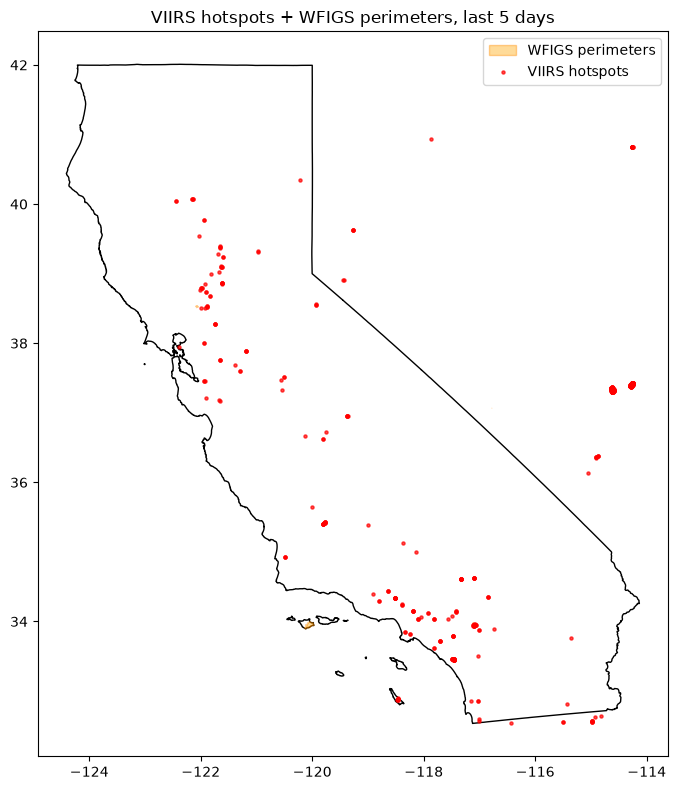

In [10]:
ca = ca.to_crs("EPSG:4326")
# clip to California bbox
minx, miny, maxx, maxy = ca.total_bounds
ca_perimeters = perimeters_gdf.cx[minx:maxx, miny:maxy]
print(f"Active perimeters in CA bbox: {len(ca_perimeters)}")

# overlay CA boundary + perimeters + VIIRS hotspots
fig, ax = plt.subplots(figsize=(8, 8))
ca.plot(ax=ax, color="none", edgecolor="black", linewidth=1)
if len(ca_perimeters) > 0:
    ca_perimeters.plot(
        ax=ax,
        color="orange",
        edgecolor="darkorange",
        alpha=0.4,
        label="WFIGS perimeters",
    )
fire_gdf.plot(ax=ax, color="red", markersize=5, alpha=0.7, label="VIIRS hotspots")
ax.set_title(f"VIIRS hotspots + WFIGS perimeters, last {days} days")
ax.legend()
plt.tight_layout()
plt.savefig(
    "plots/eda_firms_wfigs_current/w2_hotspots_perimeters.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()

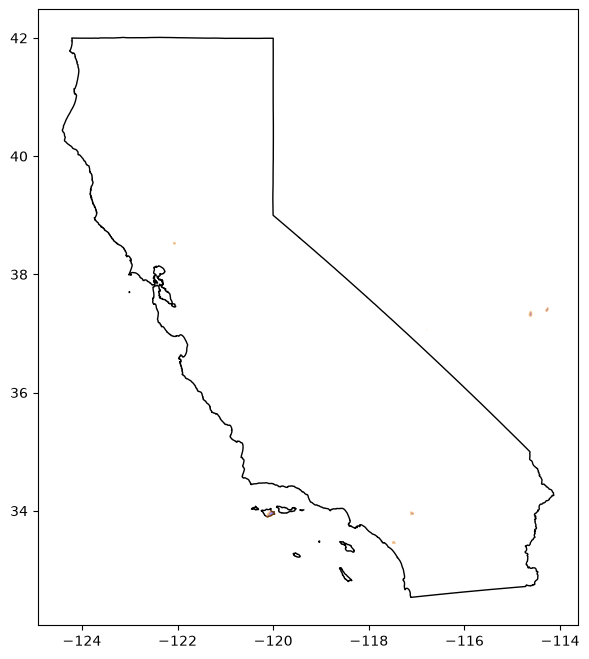

In [27]:
fig, ax = plt.subplots(figsize=(8, 8))
ca.plot(ax=ax, color="none", edgecolor="black", linewidth=1)
ca_perimeters.plot(
    ax=ax, color="blue", edgecolor="darkorange", alpha=0.4, label="WFIGS perimeters"
)
plt.savefig(
    "plots/eda_firms_wfigs_current/w3_perimeters_overlay.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()

In [11]:
print(len(ca_perimeters))
print(ca_perimeters[["poly_IncidentName", "geometry"]].head())

7
    poly_IncidentName                                           geometry
9   Santa Rosa Island  POLYGON ((-120.10605 33.90307, -120.10633 33.9...
10         US 95 MM73  POLYGON ((-116.77967 37.06625, -116.7797 37.06...
36              Putah  POLYGON ((-122.07323 38.53524, -122.07339 38.5...
55              Mateo  POLYGON ((-117.45785 33.45667, -117.45767 33.4...
68              Shore  POLYGON ((-117.09135 33.96653, -117.09135 33.9...


In [12]:
print(ca.crs)
print(perimeters_gdf.crs)

EPSG:4326
EPSG:4326


In [13]:
print(ca_perimeters[["poly_IncidentName", "poly_GISAcres"]].values)
print(ca_perimeters.geometry.is_valid.values)
print(ca_perimeters.geometry.is_empty.values)
print(ca_perimeters.total_bounds)

[['Santa Rosa Island' 18378.718851401776]
 ['US 95 MM73' 0.18]
 ['Putah' 859.8400094772314]
 ['Mateo' 1293.0]
 ['Shore' 3204.0]
 ['Kane Springs' 5723.79]
 ['Grapevine' 3949.84]]
[ True  True  True  True  True  True  True]
[False False False False False False False]
[-122.078856     33.449235   -114.24759076   38.536924  ]


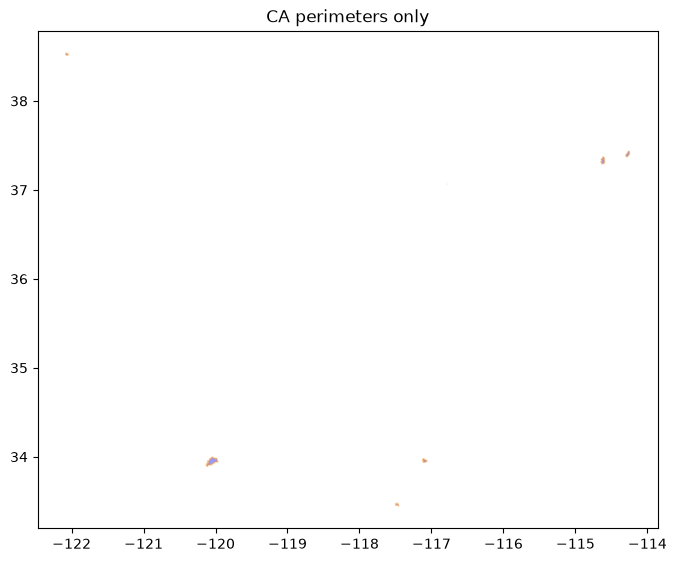

In [14]:
fig, ax = plt.subplots(figsize=(8, 8))
ca_perimeters.plot(ax=ax, color="blue", edgecolor="darkorange", alpha=0.4)
ax.set_title("CA perimeters only")
plt.show()

In [15]:
hotspots_in = gpd.sjoin(
    fire_gdf,
    ca_perimeters[["poly_IncidentName", "geometry"]],
    how="inner",
    predicate="within",
)
print(f"Hotspots inside perimeter(s): {len(hotspots_in)}")

Hotspots inside perimeter(s): 173


In [16]:
buffered = (
    ca_perimeters.to_crs("EPSG:32610").buffer(500).to_crs("EPSG:4326")
)  # 500m buffer
ca_perimeters_buf = ca_perimeters.copy()
ca_perimeters_buf["geometry"] = buffered
hotspots_in = gpd.sjoin(
    fire_gdf, ca_perimeters_buf[["geometry"]], how="inner", predicate="within"
)
print(f"Hotspots inside perimeter(s): {len(hotspots_in)}")

Hotspots inside perimeter(s): 229


     dist_km    frp confidence              acq_datetime
86       0.0  59.00          n 2026-06-15 21:08:00+00:00
104      0.0   3.53          n 2026-06-16 09:30:00+00:00
105      0.0   2.73          n 2026-06-16 09:30:00+00:00
107      0.0   2.73          n 2026-06-16 09:30:00+00:00
108      0.0   2.73          n 2026-06-16 09:30:00+00:00


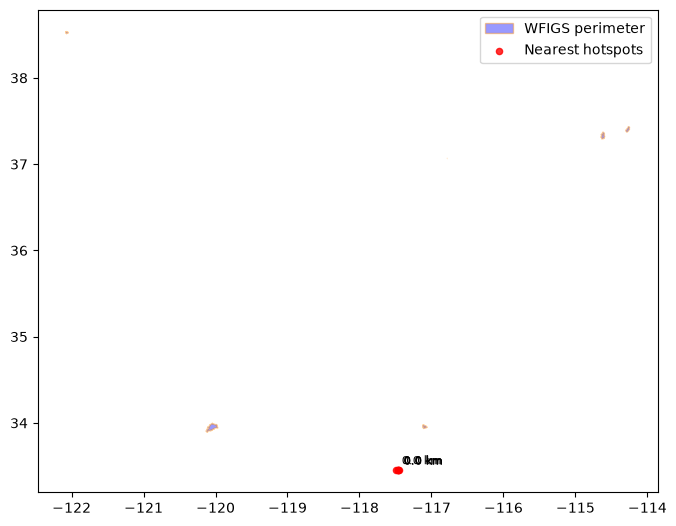

In [28]:
perimeter_utm = ca_perimeters.to_crs("EPSG:32610")
hotspots_utm = fire_gdf.to_crs("EPSG:32610")

fire_gdf["dist_km"] = hotspots_utm.geometry.distance(perimeter_utm.union_all()) / 1000

print(
    fire_gdf.nsmallest(5, "dist_km")[["dist_km", "frp", "confidence", "acq_datetime"]]
)

fig, ax = plt.subplots(figsize=(8, 8))
ca_perimeters.plot(
    ax=ax, color="blue", edgecolor="darkorange", alpha=0.4, label="WFIGS perimeter"
)
top5 = fire_gdf.nsmallest(5, "dist_km")
top5.plot(ax=ax, color="red", markersize=20, alpha=0.8, label="Nearest hotspots")
for _, row in top5.iterrows():
    ax.annotate(
        f"{row['dist_km']:.1f} km",
        xy=(row.geometry.x, row.geometry.y),
        xytext=(4, 4),
        textcoords="offset points",
        fontsize=8,
    )
ax.legend()
plt.savefig(
    "plots/eda_firms_wfigs_current/w5_nearest_hotspots.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()

In [19]:
fire_gdf["outside_perimeter"] = fire_gdf["dist_km"] > 0
outside = fire_gdf[fire_gdf["outside_perimeter"]]
print(
    f"{len(outside)} hotspots outside perimeter, closest at {outside['dist_km'].min():.1f} km"
)
print(
    f"FRP range of outside hotspots: {outside['frp'].min():.1f} - {outside['frp'].max():.1f} MW"
)

311 hotspots outside perimeter, closest at 0.0 km
FRP range of outside hotspots: 0.2 - 247.2 MW


In [20]:
date_cols = [
    c for c in ca_perimeters.columns if "date" in c.lower() or "time" in c.lower()
]
print(ca_perimeters[date_cols].T)

                                              9              10  \
poly_CreateDate                    1779319797000  1778640199000   
poly_DateCurrent                   1779412881000  1779206412000   
poly_PolygonDateTime             1779407700000.0            NaN   
attr_ContainmentDateTime                    None           None   
attr_ControlDateTime                        None           None   
attr_EstimatedCostToDate               2842958.0            NaN   
attr_FFReportApprovedDate                   None           None   
attr_FireDiscoveryDateTime         1778846226000  1778536800000   
attr_FireOutDateTime                        None           None   
attr_ICS209ReportDateTime        1780617206000.0            NaN   
attr_ICS209RptForTimePeriodFrom  1780578000000.0            NaN   
attr_ICS209RptForTimePeriodTo    1780615800000.0            NaN   
attr_InitialResponseDateTime                None           None   
attr_StratDecisionPublishDate    1779639425000.0            Na

In [21]:
print(
    "Perimeter last updated:",
    pd.to_datetime(ca_perimeters["poly_DateCurrent"].iloc[0], unit="ms", utc=True),
)
print(
    "Fire discovered: ",
    pd.to_datetime(
        ca_perimeters["attr_FireDiscoveryDateTime"].iloc[0], unit="ms", utc=True
    ),
)

Perimeter last updated: 2026-05-22 01:21:21+00:00
Fire discovered:  2026-05-15 11:57:06+00:00


In [22]:
nearby = fire_gdf[fire_gdf["dist_km"] < 15].sort_values("dist_km")
print(nearby[["dist_km", "frp", "acq_datetime", "confidence"]].to_string())

       dist_km     frp              acq_datetime confidence
300   0.000000    4.29 2026-06-18 08:50:00+00:00          n
302   0.000000   12.82 2026-06-18 08:50:00+00:00          h
303   0.000000    1.92 2026-06-18 08:50:00+00:00          n
306   0.000000    1.83 2026-06-18 08:50:00+00:00          n
307   0.000000    1.45 2026-06-18 08:50:00+00:00          n
309   0.000000    1.12 2026-06-18 08:50:00+00:00          n
310   0.000000    1.83 2026-06-18 08:50:00+00:00          n
311   0.000000    1.45 2026-06-18 08:50:00+00:00          n
313   0.000000    0.73 2026-06-18 08:50:00+00:00          n
314   0.000000    0.93 2026-06-18 08:50:00+00:00          n
463   0.000000   22.26 2026-06-18 20:11:00+00:00          n
315   0.000000    0.93 2026-06-18 08:50:00+00:00          n
317   0.000000    1.58 2026-06-18 08:50:00+00:00          n
318   0.000000    1.58 2026-06-18 08:50:00+00:00          n
319   0.000000    3.13 2026-06-18 08:50:00+00:00          n
320   0.000000    0.93 2026-06-18 08:50:

In [24]:
ca_perimeters[
    [
        "poly_IncidentName",
        "attr_PercentContained",
        "attr_FireOutDateTime",
        "attr_ContainmentDateTime",
        "attr_FireBehaviorGeneral",
        "attr_IncidentSize",
        "attr_POOCounty",
    ]
].T

,9,10,36,55,68,87,88
poly_IncidentName,Santa Rosa Island,US 95 MM73,Putah,Mateo,Shore,Kane Springs,Grapevine
attr_PercentContained,100.0,NaN,95.0,60.0,54.0,0.0,0.0
attr_FireOutDateTime,None,None,None,None,None,None,None
attr_ContainmentDateTime,None,None,None,None,None,None,None
attr_FireBehaviorGeneral,Minimal,NaN,Minimal,Minimal,Minimal,Active,Extreme
attr_IncidentSize,18379.0,0.1,860.0,1183.0,3085.0,5700.0,3949.0
attr_POOCounty,Santa Barbara,Nye,Yolo,San Diego,Riverside,Lincoln,Lincoln


^ WFIGS gets non-wildland fires, VEH -> vehicle related fire, will need to filter

In [25]:
# Filter to wildland fire perimeters only
wildland = perimeters_gdf[
    perimeters_gdf["attr_IncidentTypeCategory"].isin(["WF", "WFU"])
    | perimeters_gdf["poly_FeatureCategory"].str.contains("Wildfire", na=False)
]
print(f"All perimeters: {len(perimeters_gdf)}, wildland only: {len(wildland)}")

All perimeters: 95, wildland only: 92
